
# Ecological and Functional Abundance Analysis of Amino Acid-Degrading Enzymes

This notebook focuses exclusively on abundance, prevalence, enrichment, diversity,
and ecological-functional patterns.

Variables used:

- Site
- Halophily
- Genus
- Enzyme activities (ASNase, GLNase, SDH, GO, ADI, MGL)

Variables intentionally excluded:

- NaCl
- pH
- Phylum
- Identity
- Coverage
- Accession


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

import networkx as nx

try:
    import prince
    HAS_PRINCE = True
except:
    HAS_PRINCE = False

sns.set_theme(style="whitegrid")

df = pd.read_csv("../raw_data/atacama_enzyme_master_table.csv")

enzyme_cols = ["ASNase","GLNase","SDH","GO","ADI","MGL"]

df.head()


,Isolate,Site,NaCl,pH,Halophily,Closest_Taxon,Genus,Phylum,Identity_Percent,Query_Coverage_Percent,Accession_Number,ASNase,GLNase,SDH,GO,ADI,MGL,Enzyme_Richness,Rare_Enzyme_Richness
0,VL 1,Valle de la Luna,10,9,HA,Bacillus stercoris,Bacillus,Bacillota,98.24,100,NR_181952.1,1,0,0,0,1,0,2,0
1,VL 2,Valle de la Luna,15,9,HM,Bacillus stercoris,Bacillus,Bacillota,98.41,100,NR_181952.1,1,1,1,1,1,0,5,2
2,VL 3,Valle de la Luna,10,9,HA,Calidifontibacillus erzurumensis,Calidifontibacillus,Bacillota,96.94,100,NR_178988.1,1,1,0,0,1,0,3,0
3,VL 4,Valle de la Luna,10,9,HA,Bacillus halotolerans,Bacillus,Bacillota,99.58,100,NR_115063.1,1,1,0,0,1,0,3,0
4,VL 5,Valle de la Luna,10,9,HA,Bacillus inaquosorum,Bacillus,Bacillota,98.86,100,NR_104873.1,1,1,0,0,1,0,3,0


## 1. Global Enzyme Abundance

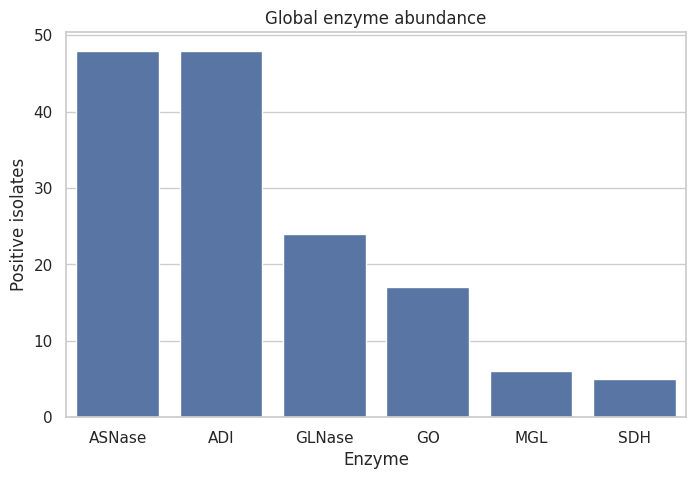

In [2]:

freq = df[enzyme_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=freq.index,y=freq.values)

plt.ylabel("Positive isolates")
plt.xlabel("Enzyme")
plt.title("Global enzyme abundance")

plt.show()


## 2. Relative Enzyme Prevalence (%)

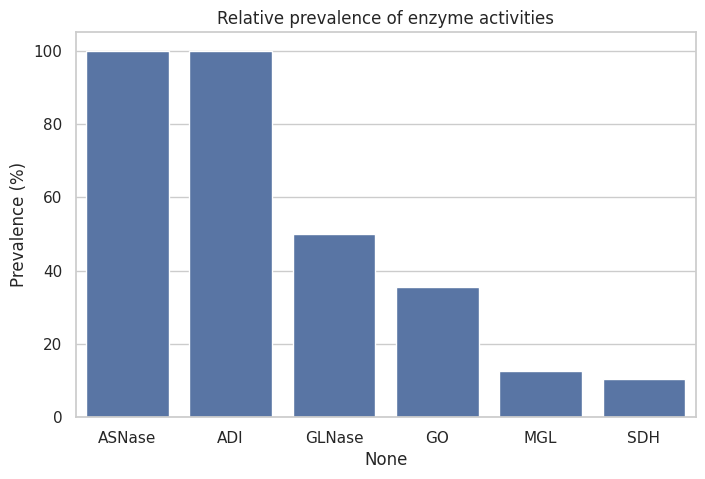

In [3]:

prev = (df[enzyme_cols].mean()*100).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=prev.index,y=prev.values)

plt.ylabel("Prevalence (%)")
plt.title("Relative prevalence of enzyme activities")

plt.show()


## 3. Enzyme Abundance by Site

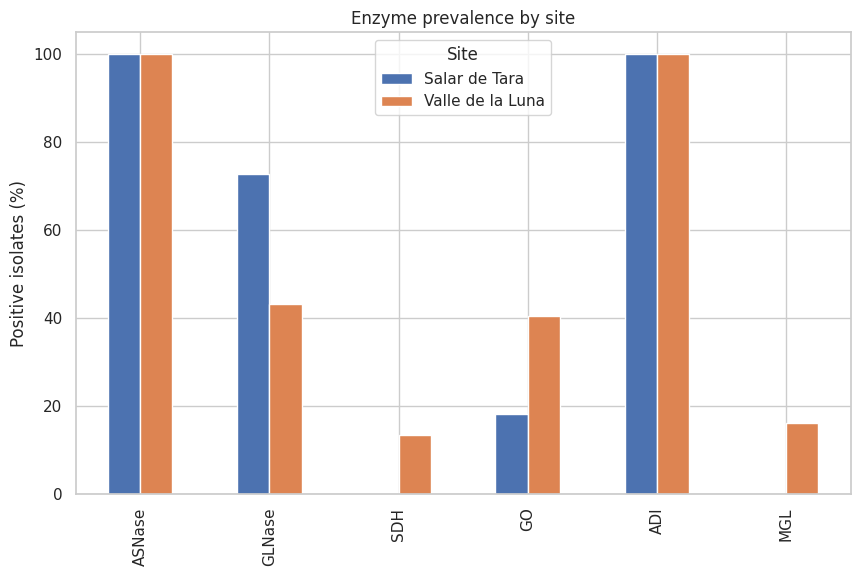

In [4]:

site_prev = df.groupby("Site")[enzyme_cols].mean().T*100

site_prev.plot(kind="bar", figsize=(10,6))

plt.ylabel("Positive isolates (%)")
plt.title("Enzyme prevalence by site")

plt.show()


## 4. Enzyme Abundance by Halophily

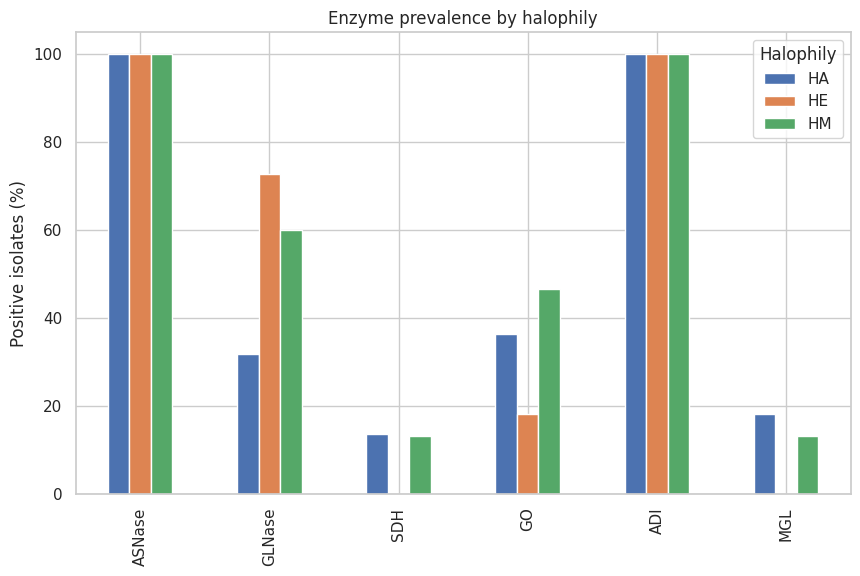

In [5]:

hal_prev = df.groupby("Halophily")[enzyme_cols].mean().T*100

hal_prev.plot(kind="bar", figsize=(10,6))

plt.ylabel("Positive isolates (%)")
plt.title("Enzyme prevalence by halophily")

plt.show()


## 5. Enzyme Abundance by Genus

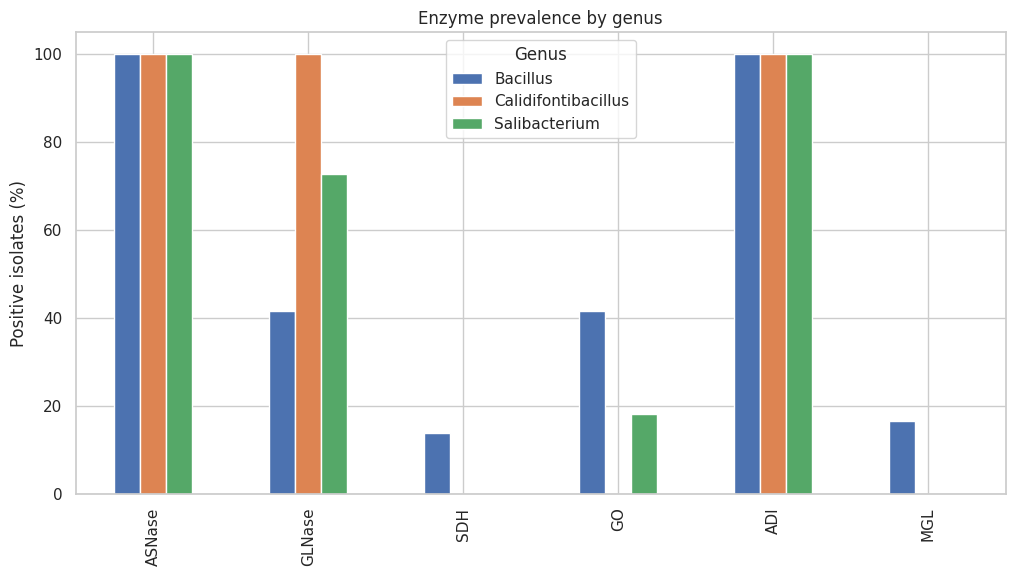

In [6]:

gen_prev = df.groupby("Genus")[enzyme_cols].mean().T*100

gen_prev.plot(kind="bar", figsize=(12,6))

plt.ylabel("Positive isolates (%)")
plt.title("Enzyme prevalence by genus")

plt.show()


## 6. Functional Richness

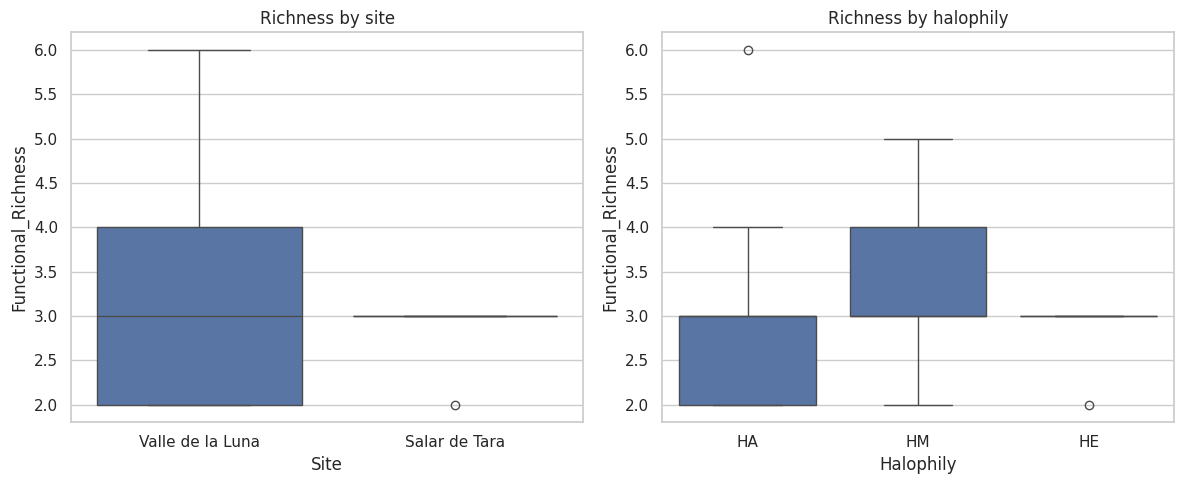

In [7]:

df["Functional_Richness"] = df[enzyme_cols].sum(axis=1)

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df,x="Site",y="Functional_Richness",ax=ax[0])
ax[0].set_title("Richness by site")

sns.boxplot(data=df,x="Halophily",y="Functional_Richness",ax=ax[1])
ax[1].set_title("Richness by halophily")

plt.tight_layout()
plt.show()


## 7. Rare Enzyme Richness

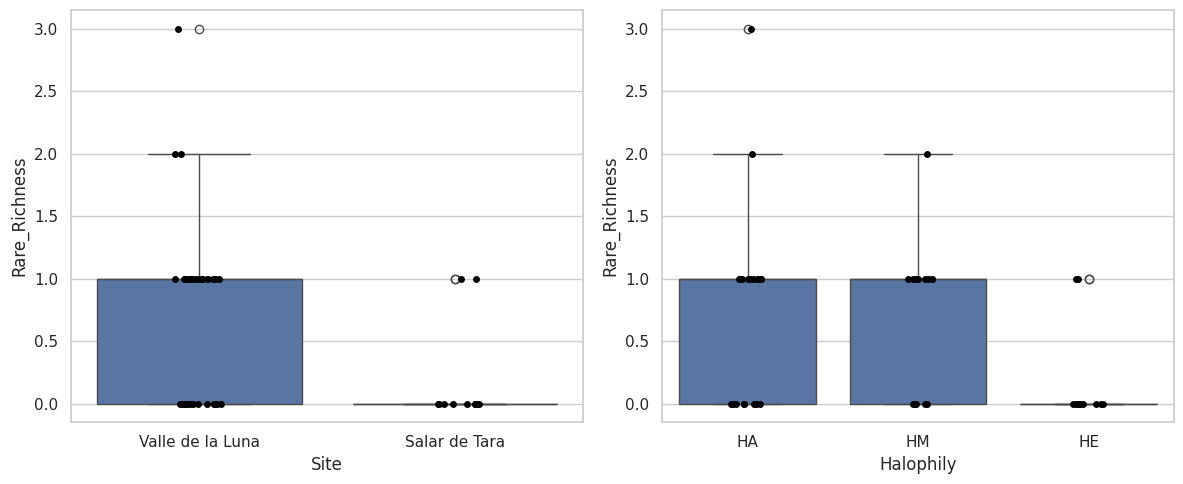

In [8]:

df["Rare_Richness"] = df[["SDH","GO","MGL"]].sum(axis=1)

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df,x="Site",y="Rare_Richness",ax=ax[0])
sns.stripplot(data=df,x="Site",y="Rare_Richness",color="black",ax=ax[0])

sns.boxplot(data=df,x="Halophily",y="Rare_Richness",ax=ax[1])
sns.stripplot(data=df,x="Halophily",y="Rare_Richness",color="black",ax=ax[1])

plt.tight_layout()
plt.show()


## 8. Clustered Functional Heatmap

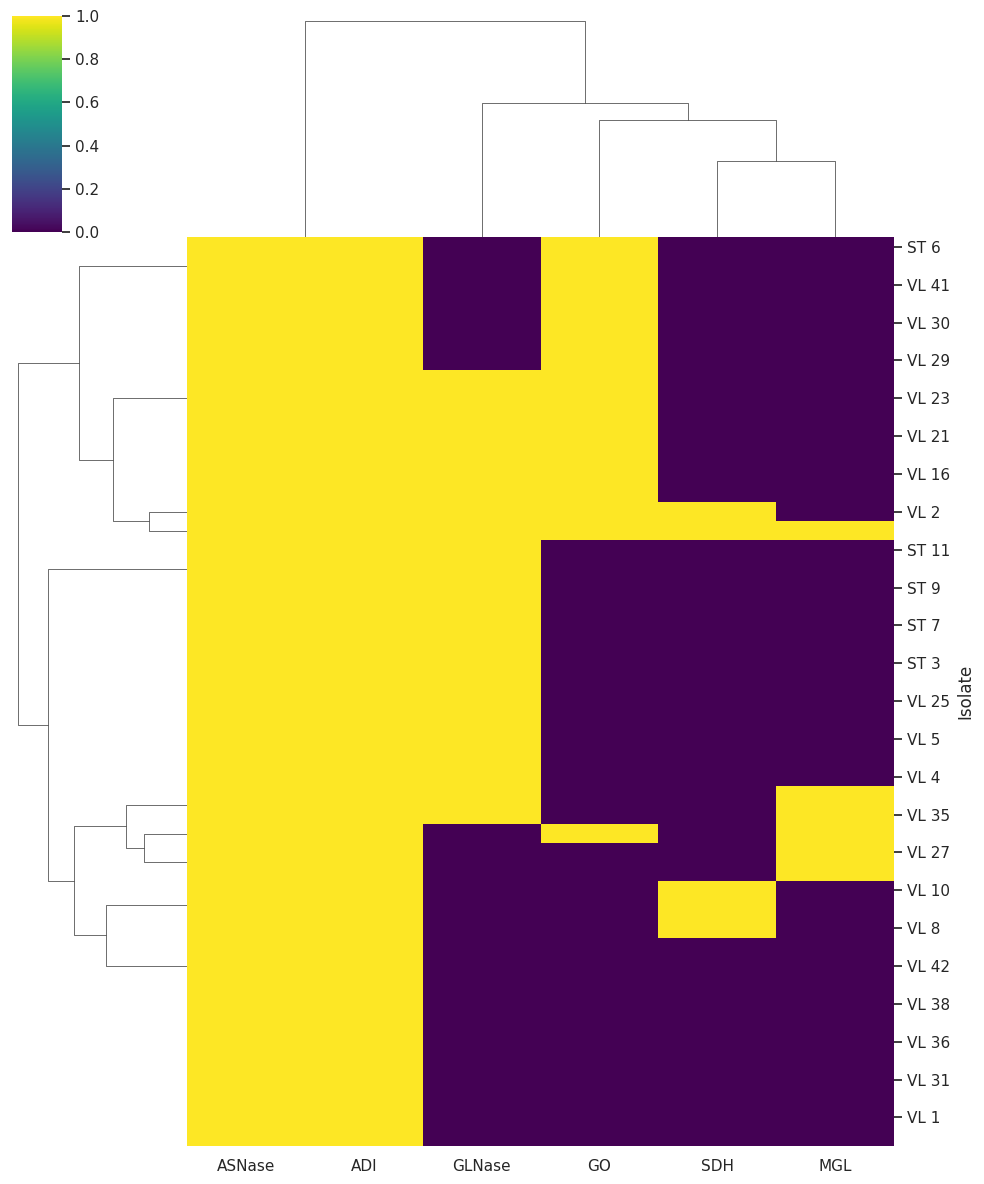

In [9]:

heat = df.set_index("Isolate")[enzyme_cols]

sns.clustermap(
    heat,
    cmap="viridis",
    metric="euclidean",
    method="ward",
    figsize=(10,12)
)

plt.show()


## 9. Enrichment Heatmap

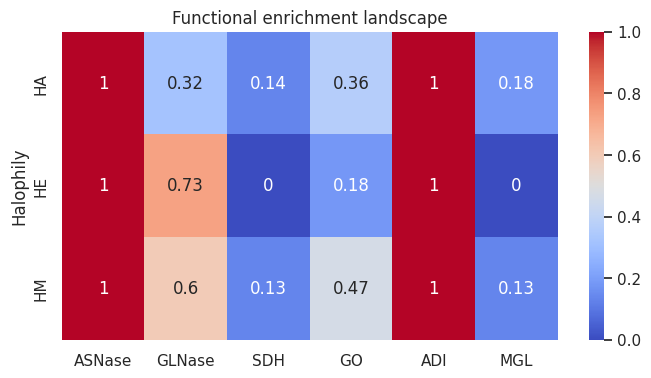

In [10]:

enrich = df.groupby("Halophily")[enzyme_cols].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    enrich,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Functional enrichment landscape")

plt.show()


## 10. Genus vs Enzyme Heatmap

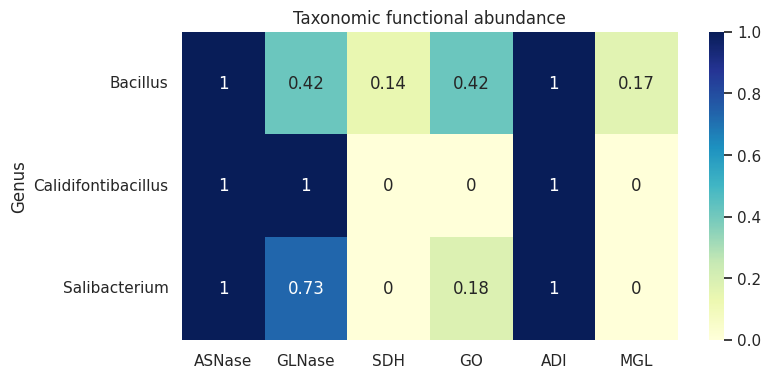

In [11]:

gen_heat = df.groupby("Genus")[enzyme_cols].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    gen_heat,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Taxonomic functional abundance")

plt.show()


## 11. Enzyme Co-occurrence

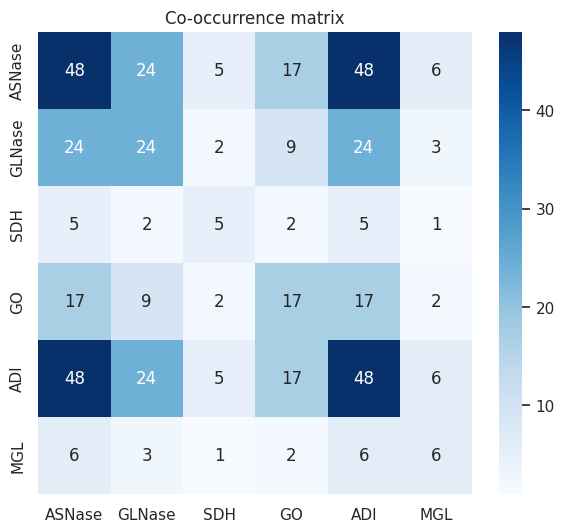

In [12]:

co = pd.DataFrame(index=enzyme_cols, columns=enzyme_cols)

for i in enzyme_cols:
    for j in enzyme_cols:
        co.loc[i,j] = ((df[i]==1)&(df[j]==1)).sum()

co = co.astype(int)

plt.figure(figsize=(7,6))

sns.heatmap(co,annot=True,cmap="Blues")

plt.title("Co-occurrence matrix")

plt.show()


## 12. PCA Functional Landscape

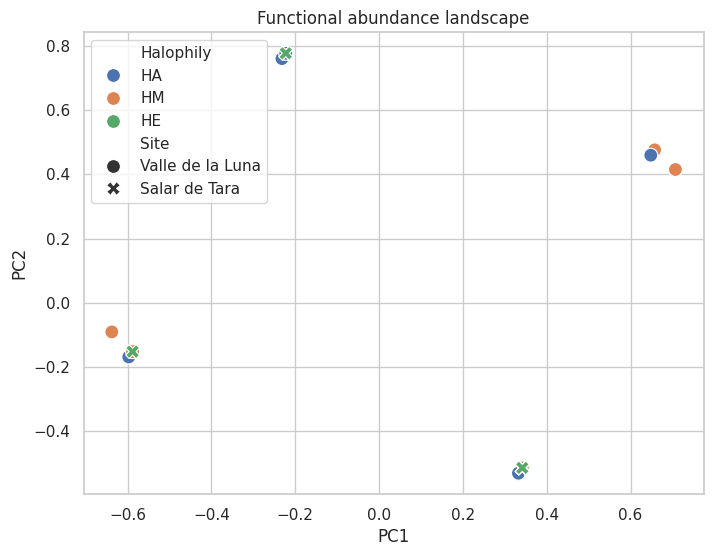

In [13]:

X = df[enzyme_cols]

coords = PCA(n_components=2).fit_transform(X)

pca_df = pd.DataFrame({
    "PC1":coords[:,0],
    "PC2":coords[:,1],
    "Halophily":df["Halophily"],
    "Site":df["Site"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Halophily",
    style="Site",
    s=100
)

plt.title("Functional abundance landscape")

plt.show()


## 13. MCA (Recommended)

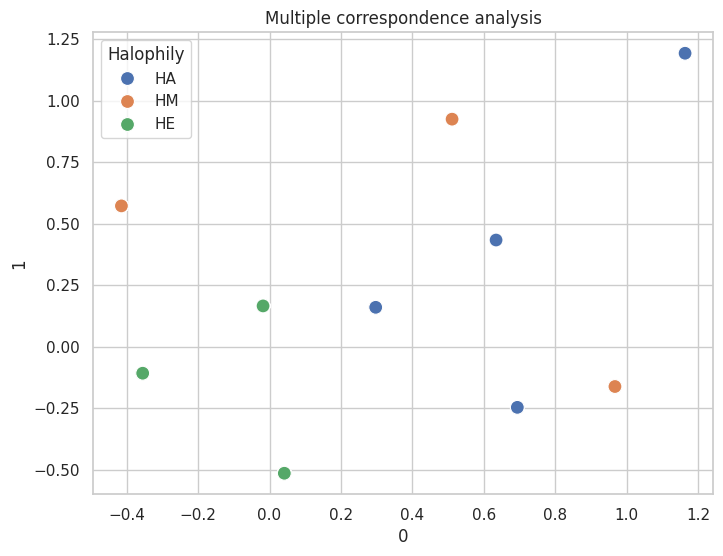

In [14]:

if HAS_PRINCE:

    mca = prince.MCA(n_components=2, random_state=42)

    coords = mca.fit_transform(df[enzyme_cols])

    coords["Halophily"] = df["Halophily"].values

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=coords,
        x=0,
        y=1,
        hue="Halophily",
        s=100
    )

    plt.title("Multiple correspondence analysis")

    plt.show()

else:
    print("Install prince package")


## 14. Bipartite Network

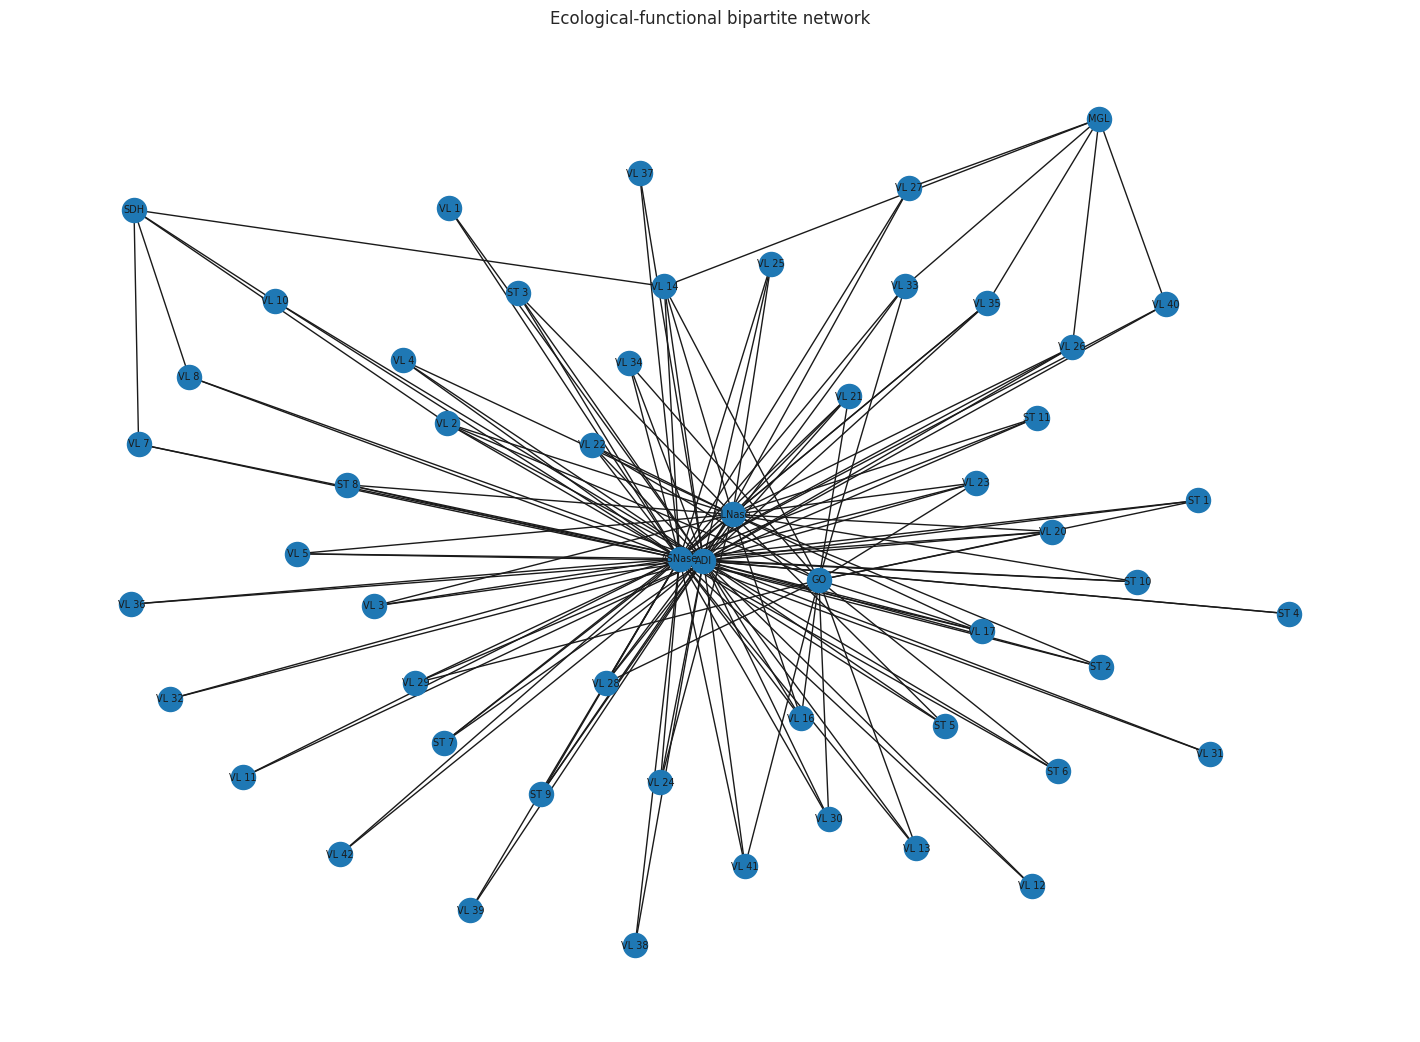

In [15]:

G = nx.Graph()

for _, row in df.iterrows():
    isolate = row["Isolate"]
    G.add_node(isolate, type="isolate")

    for enz in enzyme_cols:
        if row[enz] == 1:
            G.add_node(enz, type="enzyme")
            G.add_edge(isolate, enz)

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300,
    font_size=7
)

plt.title("Ecological-functional bipartite network")

plt.show()
